# TabICL Synthetic Prior Playground (NumPy / scikit-learn / XGBoost)

This notebook converts the previous script into an **interactive, notebook-native** playground.

What you can do:
- Generate synthetic datasets from a mixture of **MLP-SCM** and **Tree-SCM**
- Convert regression targets to **classification labels** (TabICL-style `reg2cls`)
- Inspect dataset parameters, class balance, scatter plots, and correlation heatmaps
- Use **widgets** to interactively sample datasets

> Notes:
> - If `xgboost` cannot load on your system, the Tree-SCM automatically falls back to a scikit-learn RandomForest-based backend.
> - You can change the generator defaults in the widgets panel (bottom).

In [1]:
import math
import random
from dataclasses import dataclass
from typing import Callable, List, Tuple, Dict, Optional

import numpy as np
from sklearn.preprocessing import StandardScaler

# Optional plotting (recommended)
import matplotlib.pyplot as plt

# XGBoost optional: if not available, we fall back to sklearn trees.
try:
    from xgboost import XGBRegressor
    _HAS_XGB = True
except Exception as e:
    _HAS_XGB = False
    print("XGBoost not available, TreeSCM will fall back to sklearn. Error:", e)

from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
# -----------------------------------------------------------------------------
# Activation functions
# -----------------------------------------------------------------------------
def tanh(x): return np.tanh(x)
def leaky_relu(x, negative_slope: float = 0.01): return np.where(x > 0, x, negative_slope * x)
def elu(x, alpha: float = 1.0): return np.where(x > 0, x, alpha * (np.exp(x) - 1))
def identity(x): return x
def relu(x): return np.maximum(0.0, x)
def relu6(x): return np.minimum(6.0, np.maximum(0.0, x))
def selu(x, lambda_: float = 1.0507, alpha: float = 1.67326): return lambda_ * np.where(x > 0, x, alpha * (np.exp(x) - 1))
def silu(x): return x / (1.0 + np.exp(-x))
def softplus(x): return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)
def hardtanh(x, min_val: float = -1.0, max_val: float = 1.0): return np.clip(x, min_val, max_val)
def signum(x): return np.where(x >= 0.0, 1.0, -1.0)
def sine(x): return np.sin(x)
def rbf(x): return np.exp(-(x ** 2))
def exponential(x): return np.exp(x)
def sqrt_abs(x): return np.sqrt(np.abs(x))
def unit_interval_indicator(x): return (np.abs(x) <= 1.0).astype(float)
def square(x): return x ** 2
def absolute(x): return np.abs(x)

def random_fourier_activation(x: np.ndarray, n_frequencies: int = 256) -> np.ndarray:
    """
    Random Fourier feature based activation.
    Returns an array with the SAME shape as x: (n_samples, n_features).
    """
    # Standardize inputs per feature
    x_std = (x - np.mean(x, axis=0, keepdims=True)) / (np.std(x, axis=0, keepdims=True) + 1e-6)

    # Sample frequencies and phases
    a = np.random.uniform(0.0, n_frequencies, size=(n_frequencies,))          # (nf,)
    b = np.random.uniform(0.0, 2 * np.pi, size=(n_frequencies,))             # (nf,)

    # Random weights with decaying amplitudes
    u = np.random.uniform(0.7, 3.0, size=(n_frequencies,))
    w = np.exp(-np.exp(u))
    w = w / (np.linalg.norm(w) + 1e-12)                                      # (nf,)

    # Compute sin(x*a + b) -> (n, d, nf)
    sines = np.sin(x_std[:, :, None] * a[None, None, :] + b[None, None, :])

    # Weighted sum over frequencies -> (n, d)
    return np.sum(sines * w[None, None, :], axis=2)


def sample_activation() -> Callable[[np.ndarray], np.ndarray]:
    """Sample an activation; random Fourier appears 10x more often."""
    activations = [
        tanh, lambda x: leaky_relu(x, 0.01), elu, identity, relu, relu6, selu, silu,
        softplus, hardtanh, signum, sine, rbf, sqrt_abs, exponential,
        unit_interval_indicator, square, absolute,
    ]
    activations += [random_fourier_activation] * 10
    return random.choice(activations)

In [3]:
# -----------------------------------------------------------------------------
# Sampling utilities
# -----------------------------------------------------------------------------
def sample_seq_len(min_seq: int, max_seq: int, log: bool = False) -> int:
    if min_seq >= max_seq:
        return max_seq
    if log:
        return int(np.exp(np.random.uniform(np.log(min_seq), np.log(max_seq))))
    return random.randint(min_seq, max_seq)

def sample_train_size(min_train: float, max_train: float, seq_len: int) -> int:
    low = int(min_train * seq_len)
    high = int(max_train * seq_len)
    if low >= high:
        return low
    return random.randint(low, high)

def x_sampler(seq_len: int, num_causes: int, sampling: str = "normal") -> np.ndarray:
    if sampling == "uniform":
        return np.random.rand(seq_len, num_causes)
    elif sampling == "mixed":
        X = np.empty((seq_len, num_causes), dtype=float)
        for j in range(num_causes):
            r = random.random()
            if r < 0.5:
                X[:, j] = np.random.randn(seq_len)
            elif r < 0.8:
                X[:, j] = np.random.rand(seq_len)
            else:
                cats = np.random.choice(4, size=seq_len)
                X[:, j] = cats / 3.0
        return X
    return np.random.randn(seq_len, num_causes)

In [4]:
# -----------------------------------------------------------------------------
# MLP-based Structural Causal Model
# -----------------------------------------------------------------------------
class SyntheticMLPSCM:
    def __init__(
        self,
        seq_len: int,
        num_features: int,
        num_outputs: int,
        is_causal: bool,
        num_causes: int,
        y_is_effect: bool,
        in_clique: bool,
        sort_features: bool,
        num_layers: int,
        hidden_dim: int,
        activation_fn: Callable[[np.ndarray], np.ndarray],
        noise_std: float,
        sampling: str = "normal",
    ):
        self.seq_len = seq_len
        self.num_features = num_features
        self.num_outputs = num_outputs
        self.is_causal = is_causal
        self.num_causes = num_causes
        self.y_is_effect = y_is_effect
        self.in_clique = in_clique
        self.sort_features = sort_features
        self.num_layers = max(2, num_layers)
        self.hidden_dim = max(hidden_dim, num_outputs + 2 * num_features)
        self.activation = activation_fn
        self.noise_std = noise_std
        self.sampling = sampling

        self.weights = []
        self.biases = []
        in_dim = num_causes
        for li in range(self.num_layers):
            out_dim = self.hidden_dim if li < self.num_layers - 1 else self.num_outputs
            w = np.random.randn(in_dim, out_dim) * (1.0 / math.sqrt(max(1, in_dim)))
            b = np.zeros(out_dim)
            self.weights.append(w)
            self.biases.append(b)
            in_dim = out_dim

    def __call__(self) -> Tuple[np.ndarray, np.ndarray, Dict]:
        causes = x_sampler(self.seq_len, self.num_causes, sampling=self.sampling)
        outputs = [causes]
        
        # first linear (no activation)
        with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
            x = causes @ self.weights[0] + self.biases[0]
        x = x + np.random.randn(*x.shape) * self.noise_std
        outputs.append(x)

        for i in range(1, self.num_layers):
            x = self.activation(x)
            with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
                x = x @ self.weights[i] + self.biases[i]
            x = x + np.random.randn(*x.shape) * self.noise_std
            outputs.append(x)

        outputs = outputs[2:]  # mimic TabICL drop
        X, y = self.handle_outputs(causes, outputs)
        meta = {"scm": "mlp", "seq_len": self.seq_len, "num_causes": self.num_causes}
        return X, y, meta

    def handle_outputs(self, causes: np.ndarray, outputs: List[np.ndarray]) -> Tuple[np.ndarray, np.ndarray]:
        if self.is_causal:
            outputs_flat = np.concatenate(outputs, axis=1)
            total_dim = outputs_flat.shape[1]
            if self.in_clique:
                start = random.randint(0, total_dim - self.num_outputs - self.num_features)
                perm = start + np.random.permutation(self.num_outputs + self.num_features)
            else:
                perm = np.random.permutation(total_dim - 1)

            idx_X = perm[self.num_outputs : self.num_outputs + self.num_features]
            if self.y_is_effect:
                idx_y = np.arange(total_dim - self.num_outputs, total_dim)
            else:
                idx_y = perm[: self.num_outputs]

            if self.sort_features:
                idx_X = np.sort(idx_X)

            X = outputs_flat[:, idx_X]
            y = outputs_flat[:, idx_y]
        else:
            X = causes
            y = outputs[-1]

        if y.ndim == 2 and y.shape[1] == 1:
            y = y[:, 0]
        return X, y


# -----------------------------------------------------------------------------
# Tree-based Structural Causal Model
# -----------------------------------------------------------------------------
class SyntheticTreeSCM:
    def __init__(
        self,
        seq_len: int,
        num_features: int,
        num_outputs: int,
        is_causal: bool,
        num_causes: int,
        y_is_effect: bool,
        in_clique: bool,
        sort_features: bool,
        num_layers: int,
        hidden_dim: int,
        tree_depth_lambda: float,
        tree_n_estimators_lambda: float,
        noise_std: float,
        sampling: str = "normal",
        backend: str = "xgb",  # "xgb" or "rf"
    ):
        self.seq_len = seq_len
        self.num_features = num_features
        self.num_outputs = num_outputs
        self.is_causal = is_causal
        self.num_causes = num_causes
        self.y_is_effect = y_is_effect
        self.in_clique = in_clique
        self.sort_features = sort_features
        self.num_layers = max(2, num_layers)
        self.hidden_dim = max(hidden_dim, num_outputs + 2 * num_features)
        self.tree_depth_lambda = tree_depth_lambda
        self.tree_n_estimators_lambda = tree_n_estimators_lambda
        self.noise_std = noise_std
        self.sampling = sampling
        self.backend = backend if _HAS_XGB else "rf"

    def _make_model(self, max_depth: int, n_estimators: int):
        if self.backend == "xgb":
            return XGBRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                tree_method="hist",
                multi_strategy="multi_output_tree",
                n_jobs=-1,
            )
        # portable fallback
        base = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1)
        return MultiOutputRegressor(base)

    def __call__(self) -> Tuple[np.ndarray, np.ndarray, Dict]:
        causes = x_sampler(self.seq_len, self.num_causes, sampling=self.sampling)
        outputs = [causes]

        # mimic TabICL's initial step with noise
        x = causes + np.random.randn(*causes.shape) * self.noise_std
        outputs.append(x)

        for i in range(self.num_layers):
            out_dim = self.hidden_dim if i < self.num_layers - 1 else self.num_outputs

            max_depth = 2 + int(np.random.exponential(1.0 / self.tree_depth_lambda))
            n_estimators = 1 + int(np.random.exponential(1.0 / self.tree_n_estimators_lambda))
            max_depth = min(max_depth, 4)
            n_estimators = min(n_estimators, 4)

            model = self._make_model(max_depth, n_estimators)
            y_fake = np.random.randn(self.seq_len, out_dim)
            model.fit(x, y_fake)
            x = model.predict(x)
            x = x + np.random.randn(*x.shape) * self.noise_std
            outputs.append(x)

        outputs = outputs[2:]
        X, y = self.handle_outputs(causes, outputs)
        meta = {"scm": f"tree({self.backend})", "seq_len": self.seq_len, "num_causes": self.num_causes}
        return X, y, meta

    def handle_outputs(self, causes: np.ndarray, outputs: List[np.ndarray]) -> Tuple[np.ndarray, np.ndarray]:
        if self.is_causal:
            outputs_flat = np.concatenate(outputs, axis=1)
            total_dim = outputs_flat.shape[1]
            if self.in_clique:
                start = random.randint(0, total_dim - self.num_outputs - self.num_features)
                perm = start + np.random.permutation(self.num_outputs + self.num_features)
            else:
                perm = np.random.permutation(total_dim - 1)

            idx_X = perm[self.num_outputs : self.num_outputs + self.num_features]
            if self.y_is_effect:
                idx_y = np.arange(total_dim - self.num_outputs, total_dim)
            else:
                idx_y = perm[: self.num_outputs]

            if self.sort_features:
                idx_X = np.sort(idx_X)

            X = outputs_flat[:, idx_X]
            y = outputs_flat[:, idx_y]
        else:
            X = causes
            y = outputs[-1]

        if y.ndim == 2 and y.shape[1] == 1:
            y = y[:, 0]
        return X, y

In [5]:
# -----------------------------------------------------------------------------
# Regression-to-classification conversion + dataset container
# -----------------------------------------------------------------------------
def standardize(X: np.ndarray) -> np.ndarray:
    return StandardScaler().fit_transform(X)

def remove_outliers(X: np.ndarray, threshold: float = 4.0) -> np.ndarray:
    mean = np.nanmean(X, axis=0)
    std = np.nanstd(X, axis=0)
    std[std < 1e-6] = 1.0
    return np.clip(X, mean - threshold * std, mean + threshold * std)

def num2cat(X: np.ndarray, cat_prob: float = 0.2, max_categories: int = 10) -> np.ndarray:
    if random.random() < cat_prob:
        col_prob = random.random()
        for j in range(X.shape[1]):
            if random.random() < col_prob:
                num_cats = min(max(int(random.gammavariate(1.0, 10.0)), 2), max_categories)
                qs = np.quantile(X[:, j], q=np.linspace(0, 1, num_cats + 1)[1:-1])
                X[:, j] = np.digitize(X[:, j], qs)
                X[:, j] = X[:, j] / (num_cats - 1)
    return X

def permute_classes(labels: np.ndarray) -> np.ndarray:
    uniq = np.unique(labels)
    if len(uniq) <= 1:
        return labels
    perm = np.random.permutation(len(uniq))
    mapping = {u: perm[i] for i, u in enumerate(uniq)}
    return np.array([mapping[l] for l in labels])

def balanced_binarize(y: np.ndarray) -> np.ndarray:
    return (y > np.median(y)).astype(int)

def assign_multiclass(y: np.ndarray, num_classes: int, ordered_prob: float = 0.2) -> np.ndarray:
    boundaries = np.quantile(y, q=np.linspace(0, 1, num_classes + 1)[1:-1])
    labels = np.digitize(y, boundaries)
    if random.random() >= ordered_prob:
        labels = permute_classes(labels)
    return labels.astype(int)

def reg2cls(
    X: np.ndarray,
    y: np.ndarray,
    num_classes: int,
    max_features: int,
    balanced: bool = False,
    cat_prob: float = 0.2,
    max_categories: int = 10,
    permute_features: bool = True,
    permute_labels: bool = True,
    scale_by_max_features: bool = False,
) -> Tuple[np.ndarray, np.ndarray]:
    X = num2cat(X, cat_prob=cat_prob, max_categories=max_categories)
    X = remove_outliers(X)
    X = standardize(X)

    if permute_features:
        X = X[:, np.random.permutation(X.shape[1])]

    if scale_by_max_features:
        X = X / max(1e-6, (X.shape[1] / max_features))

    if X.shape[1] < max_features:
        X = np.concatenate([X, np.zeros((X.shape[0], max_features - X.shape[1]))], axis=1)

    y = (y - np.mean(y)) / (np.std(y) + 1e-6)

    if num_classes == 2 and balanced:
        y = balanced_binarize(y)
    else:
        y = assign_multiclass(y, num_classes)

    if permute_labels:
        y = permute_classes(y)

    return X.astype(float), y.astype(int)

@dataclass
class SyntheticDataset:
    X: np.ndarray
    y: np.ndarray
    params: Dict
    meta: Dict

    @property
    def n(self): return self.X.shape[0]

    @property
    def d(self): return self.X.shape[1]

    def split(self, train_size: int):
        return (self.X[:train_size], self.y[:train_size],
                self.X[train_size:], self.y[train_size:])

    def summary(self):
        uniq, cnt = np.unique(self.y, return_counts=True)
        return {
            "shape": self.X.shape,
            "classes": dict(zip(uniq.tolist(), cnt.tolist())),
            **{k: self.params[k] for k in ["prior_type", "is_causal", "seq_len", "train_size", "num_features", "num_classes"] if k in self.params},
            **self.meta
        }

In [6]:
# -----------------------------------------------------------------------------
# Interactive generator (main API)
# -----------------------------------------------------------------------------
class SyntheticPriorGenerator:
    def __init__(
        self,
        min_features=2,
        max_features=10,
        max_classes=5,
        min_seq_len=32,
        max_seq_len=1024,
        log_seq_len=False,
        min_train_frac=0.1,
        max_train_frac=0.9,
        prob_mlp=0.7,
        seed: Optional[int] = None,
        tree_backend: str = "xgb",   # "xgb" or "rf"
    ):
        self.min_features = min_features
        self.max_features = max_features
        self.max_classes = max_classes
        self.min_seq_len = min_seq_len
        self.max_seq_len = max_seq_len
        self.log_seq_len = log_seq_len
        self.min_train_frac = min_train_frac
        self.max_train_frac = max_train_frac
        self.prob_mlp = prob_mlp
        self.tree_backend = tree_backend
        self.last: Optional[SyntheticDataset] = None

        if seed is not None:
            self.seed(seed)

    def seed(self, seed: int):
        random.seed(seed)
        np.random.seed(seed)

    def sample_params(self) -> Dict:
        seq_len = sample_seq_len(self.min_seq_len, self.max_seq_len, log=self.log_seq_len)
        train_size = sample_train_size(self.min_train_frac, self.max_train_frac, seq_len)
        num_features = random.randint(self.min_features, self.max_features)

        # binary half the time; otherwise multiclass
        num_classes = 2 if random.random() > 0.5 else random.randint(2, self.max_classes)

        prior_type = "mlp" if random.random() < self.prob_mlp else "tree"

        params = dict(
            seq_len=seq_len,
            train_size=train_size,
            num_features=num_features,
            num_classes=num_classes,
            prior_type=prior_type,

            is_causal=random.choice([True, False]),
            num_causes=max(1, int(np.random.lognormal(mean=1.5, sigma=0.5))),
            y_is_effect=random.choice([True, False]),
            in_clique=random.choice([True, False]),
            sort_features=random.choice([True, False]),

            num_layers=max(2, int(np.random.lognormal(mean=2.5, sigma=0.5))),
            hidden_dim=max(4, int(np.random.lognormal(mean=3.5, sigma=0.8))),

            noise_std=0.01 * 10 ** np.random.uniform(-2, 0),
            tree_depth_lambda=0.5,
            tree_n_estimators_lambda=0.5,
            sampling=random.choice(["normal", "uniform", "mixed"]),
            cat_prob=0.2,
        )
        return params

    def _make_scm(self, p: Dict):
        if p["prior_type"] == "mlp":
            return SyntheticMLPSCM(
                seq_len=p["seq_len"],
                num_features=p["num_features"],
                num_outputs=1,
                is_causal=p["is_causal"],
                num_causes=p["num_causes"],
                y_is_effect=p["y_is_effect"],
                in_clique=p["in_clique"],
                sort_features=p["sort_features"],
                num_layers=p["num_layers"],
                hidden_dim=p["hidden_dim"],
                activation_fn=sample_activation(),
                noise_std=p["noise_std"],
                sampling=p["sampling"],
            )
        else:
            return SyntheticTreeSCM(
                seq_len=p["seq_len"],
                num_features=p["num_features"],
                num_outputs=1,
                is_causal=p["is_causal"],
                num_causes=p["num_causes"],
                y_is_effect=p["y_is_effect"],
                in_clique=p["in_clique"],
                sort_features=p["sort_features"],
                num_layers=p["num_layers"],
                hidden_dim=p["hidden_dim"],
                tree_depth_lambda=p["tree_depth_lambda"],
                tree_n_estimators_lambda=p["tree_n_estimators_lambda"],
                noise_std=p["noise_std"],
                sampling=p["sampling"],
                backend=self.tree_backend,
            )

    def sample(self, max_tries: int = 50) -> SyntheticDataset:
        for _ in range(max_tries):
            p = self.sample_params()
            scm = self._make_scm(p)
            X_raw, y_raw, meta = scm()

            X, y = reg2cls(
                X_raw, y_raw,
                num_classes=p["num_classes"],
                max_features=p["num_features"],
                balanced=False,
                cat_prob=p["cat_prob"],
                permute_features=True,
                permute_labels=True,
                scale_by_max_features=False,
            )

            # remove constant columns
            mask = np.std(X, axis=0) > 1e-8
            if mask.sum() == 0:
                continue
            X = X[:, mask]

            # sanity checks: >=2 classes and train/test both contain all classes
            uniq = np.unique(y)
            if len(uniq) < 2:
                continue
            t = p["train_size"]
            if not (set(np.unique(y[:t])) == set(np.unique(y[t:])) == set(uniq)):
                continue

            ds = SyntheticDataset(X=X, y=y, params=p, meta=meta)
            self.last = ds
            return ds

        raise RuntimeError("Failed to generate a valid dataset after max_tries.")

    def batch(self, k: int) -> List[SyntheticDataset]:
        return [self.sample() for _ in range(k)]

In [7]:
# -----------------------------------------------------------------------------
# Visualization / exploration helpers
# -----------------------------------------------------------------------------
def show_dataset(ds: SyntheticDataset, show_corr=True):
    print(ds.summary())

    uniq, cnt = np.unique(ds.y, return_counts=True)
    plt.figure()
    plt.bar(uniq, cnt)
    plt.title("Class counts")
    plt.xlabel("class")
    plt.ylabel("count")
    plt.show()

    # visualize first 2 features vs labels (if possible)
    if ds.d >= 2:
        plt.figure()
        plt.scatter(ds.X[:, 0], ds.X[:, 1], c=ds.y, s=12)
        plt.title("First two features colored by label")
        plt.xlabel("X[:,0]")
        plt.ylabel("X[:,1]")
        plt.show()

    if show_corr and ds.d >= 2:
        C = np.corrcoef(ds.X.T)
        plt.figure()
        plt.imshow(C, aspect="auto")
        plt.title("Feature correlation heatmap")
        plt.colorbar()
        plt.show()

{'shape': (896, 10), 'classes': {0: 179, 1: 179, 2: 180, 3: 178, 4: 180}, 'prior_type': 'mlp', 'is_causal': False, 'seq_len': 896, 'train_size': 483, 'num_features': 8, 'num_classes': 5, 'scm': 'mlp', 'num_causes': 10}


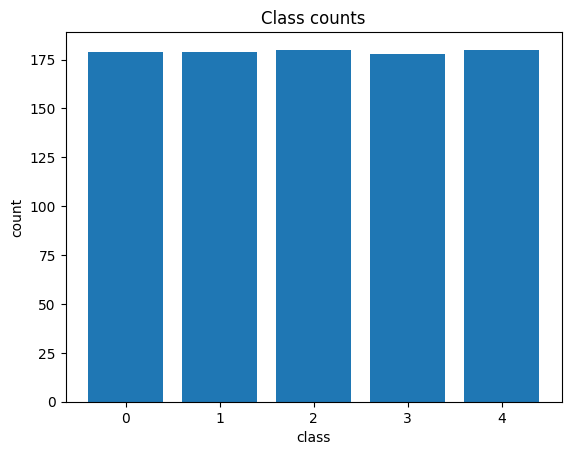

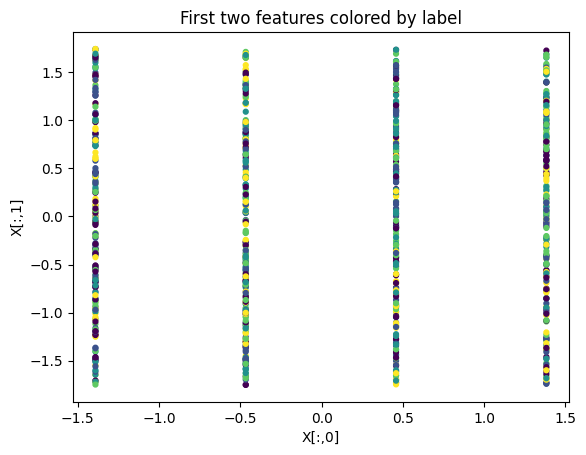

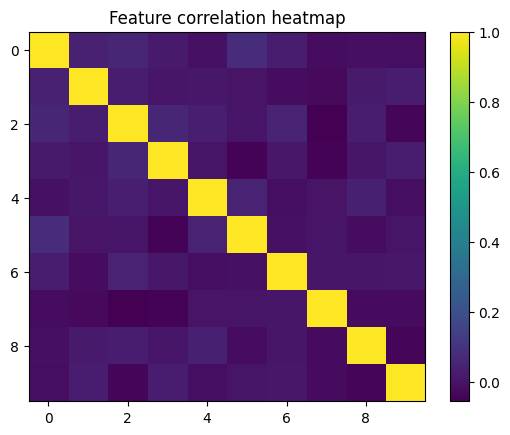

Train: (483, 10) Test: (413, 10)


In [8]:
# -----------------------------------------------------------------------------
# Quick demo (run this cell)
# -----------------------------------------------------------------------------
gen = SyntheticPriorGenerator(seed=0)
ds = gen.sample()
show_dataset(ds)

# Access train/test split
Xtr, ytr, Xte, yte = ds.split(ds.params["train_size"])
print("Train:", Xtr.shape, "Test:", Xte.shape)

In [9]:
# -----------------------------------------------------------------------------
# Widgets: interactive dataset sampling
# -----------------------------------------------------------------------------
import ipywidgets as widgets
from IPython.display import display, clear_output

seed_w = widgets.IntText(value=0, description="seed")
max_feat_w = widgets.IntSlider(value=10, min=2, max=200, step=1, description="max_features")
max_seq_w = widgets.IntSlider(value=256, min=32, max=4096, step=32, description="max_seq_len")
max_cls_w = widgets.IntSlider(value=5, min=2, max=20, step=1, description="max_classes")
pmlp_w = widgets.FloatSlider(value=0.7, min=0.0, max=1.0, step=0.05, description="P(MLP)")
tree_backend_w = widgets.Dropdown(options=["xgb", "rf"], value="xgb", description="tree")

btn = widgets.Button(description="Generate dataset", button_style="success")
out = widgets.Output()

def on_click(_):
    with out:
        clear_output(wait=True)
        gen = SyntheticPriorGenerator(
            max_features=max_feat_w.value,
            max_seq_len=max_seq_w.value,
            max_classes=max_cls_w.value,
            prob_mlp=pmlp_w.value,
            seed=seed_w.value,
            tree_backend=tree_backend_w.value,
        )
        ds = gen.sample()
        show_dataset(ds)

btn.on_click(on_click)

display(widgets.VBox([
    widgets.HBox([seed_w, tree_backend_w]),
    max_feat_w, max_seq_w, max_cls_w, pmlp_w,
    btn, out
]))